Exam 1

Exam 1
Author: Kayce Johnson


In [1]:
# Package Imports - copy and paste
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

In [2]:
file_location = 'https://joannabieri.com/introdatascience/data/lego_sample.csv'
DF = pd.read_csv(file_location)
show(DF)


Loading ITables v2.6.2 from the internet... (need help?)


Problem 1

(a) There are 14 variables (columns) and 75 observations (rows)

(b) Names of all the variable


In [3]:
DF.keys()


Index(['item_number', 'set_name', 'theme', 'pieces', 'price', 'amazon_price',
       'year', 'ages', 'pages', 'minifigures', 'packaging', 'weight',
       'unique_pieces', 'size'],
      dtype='object')

(c)

item_number - numerical

set_name - categorical 

theme - categorical

pieces - numerical

price - numerical

amazon_price - numerical

year - numerical

ages - categorical

pages - numerical

minifigures - numerical

packaging - categorical

weight - numerical

unique_pieces - numerical

size - categorical

In [4]:
DF.describe()


,item_number,pieces,price,amazon_price,year,pages,minifigures,unique_pieces
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,65.000000,75.000000
mean,37498.493333,196.453333,32.136667,39.393733,2019.053333,73.213333,2.615385,96.666667
std,20461.267542,213.914121,27.747263,33.301259,0.820239,76.949842,2.133749,89.471018
min,10859.000000,6.000000,4.990000,6.290000,2018.000000,1.000000,1.000000,5.000000
25%,10916.500000,37.000000,9.990000,17.980000,2018.000000,14.000000,1.000000,30.000000
50%,41378.000000,93.000000,19.990000,29.990000,2019.000000,44.000000,2.000000,61.000000
75%,60193.000000,323.500000,39.990000,53.935000,2020.000000,116.000000,3.000000,151.000000
max,60267.000000,897.000000,149.990000,184.990000,2020.000000,389.000000,15.000000,411.000000


I notice that there is a very high range of number of pieces per set - ranging from as few as 6 to as many as 897. With the average being nearly 200 (198.45). This tells me that there are nota s many high pieces sets since the average is well below half and the standard deviation is over 200 (213.9).

I also see that there is a much smaller spread for pages. This is inersting ot think that you don't need that many more ages to descrive sets iwth higher piece counts and makes me wonder if larger sets (by piece count) necessarily means more complicated. There could be repetition that cuts down on page counts.

I notice this data is only giving information on numerical data (of course), and although the item_number is a number, it doesn't make sense to think about it as a piece of numerical data, because they shoul be preserved in any alaysis. Similar for ear, although looking at averages makes more sense here.


In [5]:
relevant_columns = ['set_name', 'theme', 'ages', 'minifigures', 'size']
DF[relevant_columns]


,set_name,theme,ages,minifigures,size
0,My First Ladybird,DUPLO®,Ages_1½-3,NaN,Large
1,My First Race Car,DUPLO®,Ages_1½-3,NaN,Large
2,My First Celebration,DUPLO®,Ages_1½-3,NaN,Large
3,Large Playground Brick Box,DUPLO®,Ages_2-5,2.0,Large
4,Farmers' Market,DUPLO®,Ages_2-5,3.0,Large
...,...,...,...,...,...
70,Monster Truck,City,Ages_5+,1.0,Small
71,Construction Bulldozer,City,Ages_4+,2.0,Small
72,Tuning Workshop,City,Ages_6+,7.0,Small
73,Ocean Exploration Ship,City,Ages_7+,8.0,Small


In [6]:
relevant_columns = ['set_name', 'theme', 'ages', 'minifigures', 'size']
DF[relevant_columns]


,set_name,theme,ages,minifigures,size
0,My First Ladybird,DUPLO®,Ages_1½-3,NaN,Large
1,My First Race Car,DUPLO®,Ages_1½-3,NaN,Large
2,My First Celebration,DUPLO®,Ages_1½-3,NaN,Large
3,Large Playground Brick Box,DUPLO®,Ages_2-5,2.0,Large
4,Farmers' Market,DUPLO®,Ages_2-5,3.0,Large
...,...,...,...,...,...
70,Monster Truck,City,Ages_5+,1.0,Small
71,Construction Bulldozer,City,Ages_4+,2.0,Small
72,Tuning Workshop,City,Ages_6+,7.0,Small
73,Ocean Exploration Ship,City,Ages_7+,8.0,Small


I did not include packaging type. Unless I was looking at the packaging specifically, it doesn't necessarily give me any information about the sets each package contains.


In [7]:
show(DF.value_counts('set_name'))
show(DF.value_counts('theme'))
show(DF.value_counts('ages'))
show(DF.value_counts('minifigures'))
show(DF.value_counts('size'))

Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


There are many more small sets, which makes sense as many are geared towards younger ages. Also, there are a lot of categories of age ranges, but many of them overlap. It would be interesting to graph this and see what the spread of age range actual was, and how many sets were created for each age range, without the overlap.  


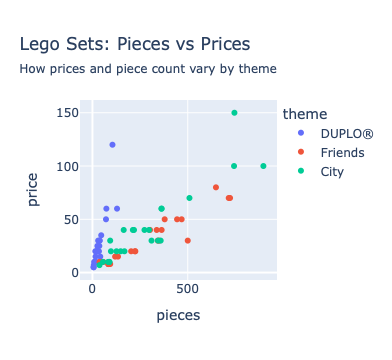

In [8]:
#Problem 3
#(a)
fig = px.scatter(DF,
                 x='pieces',
                 y='price',
                 color='theme',
                 title='Lego Sets: Pieces vs Prices',
                 subtitle='How prices and piece count vary by theme',
                 hover_data='set_name')
fig.show()

(b)

The more expensive sets do have a positive correlation with more pieces. More so in the Friends and City themes, which makes sense since Duplo are geared towards younger children.

The most expensive set is 'Ocean Exploration Set' at $149.99

There is a difference in the themes. Sepcifically, DUPLO does not get much pricier even with their highest piece-count sets. This may be because they are geared towards the youngest children. Although city does have several more expensive pieces then Friends, there is a similar correlation in those two themes.


Problem 4
(a) 

In [9]:
DF['price_diff'] = DF['amazon_price'] - DF['price']
difference_columns = ['set_name', 'price_diff']
show(DF[difference_columns])
#Positive values mean that the price on Amazon is greater than the retail price.


Loading ITables v2.6.2 from the internet... (need help?)


In [10]:
#(b)
price_columns = ['theme', 'price_diff']
DF[price_columns].groupby('theme').describe()


price_diff                                                     
             count    mean        std    min   25%   50%    75%     max
theme                                                                  
City          25.0  5.3996  15.243677 -13.99 -4.01 -1.00  12.00   39.96
DUPLO®        25.0  7.3924  16.996152  -5.00 -2.00  0.00  11.01   69.00
Friends       25.0  8.9792  24.047927  -9.99 -0.04  3.96   8.94  115.00

There is the biggest swing of price different on the Friends set, as seen by the highest standard deviation.

The best price difference is in the City collection, so the Amazon price may on average be better (lowest minimum and 50% still a negative value)

There is not a great benefit to shopping on Amazon for legos- doing price checks is worthwhile since its not a guarantee the prices will be better, on average. In fact, the average is positie which means that in general, the legos cost more on Aamzon.

Even though City has the highest priced item, the average is the lowest for the price difference, which is very interesting and not what I would expect.


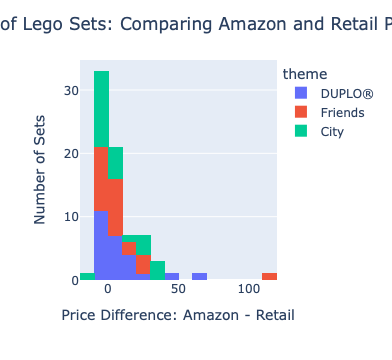

In [11]:
#(c)
fig = px.histogram(DF,
                   x='price_diff',
                   color = 'theme')
fig.update_layout(title= 'Price Difference of Lego Sets: Comparing Amazon and Retail Prices, by Theme',
                  title_x=.5,
                  xaxis_title='Price Difference: Amazon - Retail',
                  yaxis_title='Number of Sets')

fig.show()

This graph shoes that the majority of set are within $10 of eachother - either direction. With the exception of a few outliers of Amazon prices being much higher on one DUPLO and one friends set, the majority have a pretty comparable price. It is interesting to me that the prize would be higher on Amazon ever. My understanding is that poeple use that service to save money, but if you have to pay to use it and you pay more for the product, what are the benefits of using this service? Is it just the free shipping? Is it the illusion of savings? I would be surious to know more.

Problem 5
(a)
Ocean Exploration Ship is the highest retail price.

In [12]:
price_columns = ['set_name', 'price']
DF_price_sorted = DF[price_columns].sort_values('price', ascending=False)
show(DF_price_sorted)


lookup = 149.99
my_columns = DF.keys()
mask = DF['price']==lookup
show(DF[mask][my_columns])


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


(b)
The highest priced set on Amazon is the Friendship House set.

In [46]:
price_columns = ['set_name', 'amazon_price']
DF_amzprice_sorted = DF[price_columns].sort_values('amazon_price', ascending=False)
show(DF_amzprice_sorted)


lookup = 184.99
my_columns = DF.keys()
mask2 = DF['amazon_price']==lookup
show(DF[mask2][my_columns])


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


In [13]:
 #(c)
mask3 = (DF['price'] >100) | (DF['amazon_price'] >100)
show(DF[mask3])


Loading ITables v2.6.2 from the internet... (need help?)


In [14]:
#Problem 6
#(a)
maskyear = DF['year'].drop_duplicates()
show(maskyear)

Loading ITables v2.6.2 from the internet... (need help?)


In [15]:
my_columns = ['price', 'year']
show(DF[my_columns].groupby('year')['price'].mean())
my_amz_columns = ['amazon_price', 'year']
show(DF[my_amz_columns].groupby('year')['amazon_price'].mean())


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


The average price has gone up significantly from 2018 to 2020, with no significant change from 2018 to 2019.

Average Amazon price has done the inverse and decreased from 2018 to 2019 significantly, with an increase into 2020. Both are similar in 2020.

In [16]:
#(b)
my_piececolumns = ['pieces', 'year']
show(DF[my_piececolumns].groupby('year')['pieces'].mean())


Loading ITables v2.6.2 from the internet... (need help?)


The number of pieces, on average, is increasing over the 3 years.


In [17]:
#(c)
mini_columns = ['set_name', 'minifigures']
show(DF[mini_columns].sort_values('minifigures', ascending=False))


Loading ITables v2.6.2 from the internet... (need help?)


People-Pack Outdoor Adventures have the most minifigures.

In [18]:
zero_minifigures = DF.groupby('minifigures')['minifigures'].value_counts()
zero_minifigures = zero_minifigures.reset_index().rename(columns={"index": "value", 0: "count"})
show(zero_minifigures)
show(zero_minifigures.sum())


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


Since there are 75 total observations, and 65 have at least one mini figure, then 10 have zero or none.

To find this, I first looked at the total number of observations, which we found in the first part of this problem (75). Then, when counting the sets with different minifigure counts, I saw that it was only counting figures with at least one, so I added up the total number of sets it counted (65) and subtracted that from the total number of mini sets, leaving me with the 10 that had zero of NaN.


Problem 7


In [19]:
show(DF.value_counts('ages'))

Loading ITables v2.6.2 from the internet... (need help?)


In [25]:
mask_age6 = (DF['ages'] == 'Ages_6+') | (DF['ages'] == 'Ages_5+') | (DF['ages'] == 'Ages_2+') | (DF['ages'] == 'Ages_5-12') | (DF['ages'] == 'Ages_6-12') | (DF['ages'] == 'Ages_1 1/2+') | (DF['ages'] == 'Ages_4+')
DF_age6 = DF[mask_age6]
mask_2020 = DF_age6['year'] == 2020
DF_new_age6 = DF_age6[mask_2020]
decision_columns = ['set_name', 'pieces', 'price', 'amazon_price']
DF_decision = DF_new_age6[decision_columns]
show(DF_decision)


Loading ITables v2.6.2 from the internet... (need help?)


In [ ]:
lookup = 

In [26]:
lookup = 'Tuning Workshop'
mask = DF['set_name']==lookup
show(DF[mask])

Loading ITables v2.6.2 from the internet... (need help?)


I recommend buying the Tuning Workshop set. It is the largest set (897 pieces) that is age appropriate (6+). In my opinion, we should go all out, especially for young children. I pulled the entire data set, but I looked specifically at the retail and Amazon prices in case there was a large discerpancy, so we could pick the next largest set so we do not have to buy from Amazon. A local retailer will be the same price (99.99).